## Setup & Config

### 📦 Step 1.1 — Install Dependencies, Import Libraries & Define Configuration

This cell performs three key tasks:

1. **Install required packages** — `torch`, `torchvision`, `matplotlib`, `pillow`, and `numpy` are installed via `pip`. These form the core stack for deep learning, image processing, and plotting.

2. **Import all necessary libraries** — We import PyTorch for tensors and models, `torchvision.transforms` for image augmentation, `PIL` for image loading, `matplotlib` for plotting bounding boxes, `numpy` for array utilities, and Python built-ins (`os`, `glob`, `random`, `collections.defaultdict`) for file I/O and data organisation.

3. **Define the global `CONFIG` dictionary** — This single dict stores:
   - `MOT16_ROOT`: the path to the dataset on Google Drive.
   - `TRAIN_SEQUENCES`: the seven official MOT16 training sequences.
   - `IMAGE_SIZE`: the (min_size, max_size) expected by Faster R-CNN's internal resize.
   - `DEVICE`: automatically selects Apple MPS → CUDA GPU → CPU, ensuring the notebook runs on any platform.

**Output:** prints the selected device (e.g., `cuda`) confirming GPU availability.

In [3]:
!pip install torch torchvision matplotlib pillow numpy

%matplotlib inline

import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
import glob
import random
from collections import defaultdict

CONFIG = {
    "MOT16_ROOT": "/content/drive/MyDrive/MOT16",
    "TRAIN_SEQUENCES": [
        "MOT16-02", "MOT16-04", "MOT16-05", "MOT16-09",
        "MOT16-10", "MOT16-11", "MOT16-13"
    ],
    "IMAGE_SIZE": (800, 1333),
    "DEVICE": torch.device(
        "mps" if torch.backends.mps.is_available()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )
}

print(f"Device: {CONFIG['DEVICE']}")

Device: cuda


### 📁 Step 1.2 — Mount Google Drive

This cell mounts Google Drive into the Colab filesystem at `/content/drive`, making the MOT16 dataset (stored in `MyDrive/MOT16`) accessible as local files.

- If Drive is already mounted, it skips re-mounting and prints a confirmation message.
- This step is **Colab-specific** — if running locally, you would replace this with a direct path to your dataset folder.

**Output:** `Drive already mounted at /content/drive` — confirms the dataset is accessible.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Ground Truth Parser

### 📋 Step 1.3 — Parse MOT16 Ground-Truth Annotations

The MOT16 ground-truth file (`gt.txt`) stores one annotation per line in CSV format:
```
frame, id, bb_left, bb_top, bb_width, bb_height, conf, class, visibility
```

`parse_gt_file()` processes this file with the following logic:

1. **Read each line** and split by comma to extract: frame number, object ID, bounding-box coordinates (left, top, width, height), confidence flag, and class label.

2. **Filter annotations** — only rows where `conf == 1` (confirmed detection) AND `cls == 1` (pedestrian class) are kept. This removes ignored regions, vehicles, and other non-pedestrian classes.

3. **Convert from (left, top, width, height) → (x_min, y_min, x_max, y_max)** — the `[x_min, y_min, x_max, y_max]` format ("xyxy") is what PyTorch's Faster R-CNN expects.

4. **Return a `defaultdict(list)`** mapping each frame number to a list of `{"id": ..., "bbox": [...]}` dicts.

**Quick test:** We parse `MOT16-02/gt/gt.txt` and confirm 600 frames with 17,833 pedestrian annotations.

In [5]:
def parse_gt_file(file_path):
    annotations = defaultdict(list)
    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split(",")
            frame = int(parts[0])
            obj_id = int(parts[1])
            bb_left = float(parts[2])
            bb_top = float(parts[3])
            bb_width = float(parts[4])
            bb_height = float(parts[5])
            conf = int(parts[6])
            cls = int(parts[7])
            # only keep confirmed pedestrian annotations
            if conf != 1 or cls != 1:
                continue
            x_min = bb_left
            y_min = bb_top
            x_max = bb_left + bb_width
            y_max = bb_top + bb_height
            annotations[frame].append({
                "id": obj_id,
                "bbox": [x_min, y_min, x_max, y_max]
            })
    return annotations

test_gt_path = os.path.join(CONFIG["MOT16_ROOT"], "train", "MOT16-02", "gt", "gt.txt")
test_annotations = parse_gt_file(test_gt_path)
total_annots = sum(len(v) for v in test_annotations.values())
print(f"MOT16-02: {len(test_annotations)} frames with annotations, {total_annots} total annotations")

MOT16-02: 600 frames with annotations, 17833 total annotations


## Data Augmentation

### 🎨 Step 1.4 — Define and Visualise Data Augmentation Pipeline

Data augmentation is critical for training robust detection and re-identification models. `get_train_augmentation()` returns a `transforms.Compose` pipeline with three stochastic transforms:

| Transform | Purpose | Parameters |
|-----------|---------|------------|
| `ColorJitter` | Randomly varies brightness, contrast, saturation, and hue to simulate different lighting conditions | ±40% brightness/contrast/saturation, ±10% hue |
| `RandomGrayscale` | Converts 10% of images to grayscale, forcing the model to rely on shape rather than colour | p=0.1 |
| `GaussianBlur` | Applies a 5×5 Gaussian blur with random σ, simulating motion blur / out-of-focus frames | σ ∈ [0.1, 2.0] |

**Key design choice:** These augmentations are **colour/texture-only** — they do not alter geometry (no random crop/flip/rotate). This matters because the bounding-box coordinates from `gt.txt` must remain valid; spatial augmentations would require re-mapping all boxes, adding unnecessary complexity at this stage.

**Visualisation:** We load one frame from `MOT16-02` and display it alongside three random augmentations, showing how the same scene looks under different synthetic lighting and blur conditions.

**Output:** A 1×4 figure — the original image followed by three augmented variants.

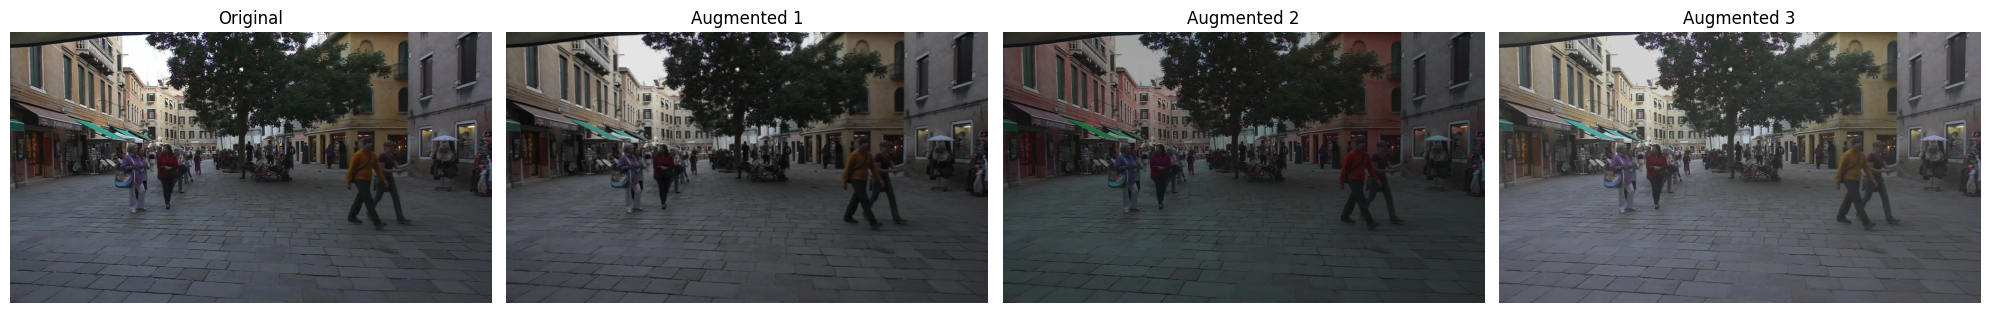

In [6]:
def get_train_augmentation():
    return transforms.Compose([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    ])

sample_img_path = sorted(glob.glob(
    os.path.join(CONFIG["MOT16_ROOT"], "train", "MOT16-02", "img1", "*.jpg")
))[0]
sample_img = Image.open(sample_img_path).convert("RGB")
aug = get_train_augmentation()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(sample_img)
axes[0].set_title("Original")
axes[0].axis("off")
for i in range(1, 4):
    axes[i].imshow(aug(sample_img))
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## MOT Dataset Class

### 📦 Step 1.5 — Define the `MOTDataset` Class and Collation Function

This cell defines the core `MOTDataset` class, which wraps a **single MOT16 sequence** as a PyTorch `Dataset`:

1. **`__init__`** — Scans `img1/` for all `.jpg` frames (sorted numerically), and parses `gt/gt.txt` using our `parse_gt_file()` function from earlier.

2. **`__getitem__`** — For a given index:
   - Opens the corresponding frame as an RGB PIL Image.
   - Retrieves ground-truth annotations for that frame (using 1-based indexing, as MOT16 frames start at 1).
   - Optionally applies the data augmentation pipeline.
   - Converts the image to a `float32` tensor via `transforms.ToTensor()` (scales pixel values to [0, 1]).
   - Packs bounding boxes as `float32`, labels as `int64` (all 1 = pedestrian), and object IDs as `int64` into a `target` dict.
   - **Edge case:** If a frame has no annotations, returns zero-sized tensors `(0, 4)` for boxes and `(0,)` for labels/IDs, preventing crashes during training.

3. **`collate_fn`** — Since images can have different numbers of bounding boxes, the default `DataLoader` collation (which tries to stack tensors) would fail. This custom function simply returns a **list of images** and a **list of target dicts**, which is the format Faster R-CNN's `forward()` expects.

**Quick test:** We instantiate the dataset for `MOT16-02` with augmentation enabled.

**Output:** `MOT16-02 dataset length: 600` — confirms all 600 frames are indexed.

In [7]:
class MOTDataset(torch.utils.data.Dataset):
    def __init__(self, sequence_path, transform=None):
        self.sequence_path = sequence_path
        self.transform = transform
        self.frame_paths = sorted(
            glob.glob(os.path.join(sequence_path, "img1", "*.jpg")),
            key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
        )
        gt_path = os.path.join(sequence_path, "gt", "gt.txt")
        self.annotations = parse_gt_file(gt_path)

    def __len__(self):
        return len(self.frame_paths)

    def __getitem__(self, idx):
        img = Image.open(self.frame_paths[idx]).convert("RGB")
        # MOT16 frames are 1-indexed
        frame_number = idx + 1
        frame_annots = self.annotations.get(frame_number, [])

        if self.transform:
            img = self.transform(img)

        img_tensor = transforms.ToTensor()(img)

        if len(frame_annots) > 0:
            boxes = torch.as_tensor([a["bbox"] for a in frame_annots], dtype=torch.float32)
            labels = torch.ones(len(frame_annots), dtype=torch.int64)
            obj_ids = torch.as_tensor([a["id"] for a in frame_annots], dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
            obj_ids = torch.zeros(0, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "obj_ids": obj_ids
        }
        return img_tensor, target


def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return images, targets


mot02_path = os.path.join(CONFIG["MOT16_ROOT"], "train", "MOT16-02")
dataset = MOTDataset(mot02_path, transform=get_train_augmentation())
print(f"MOT16-02 dataset length: {len(dataset)}")

MOT16-02 dataset length: 600


## DataLoader Test

### 🔄 Step 1.6 — Test the DataLoader

This cell creates a `DataLoader` around our `MOTDataset` and fetches **one batch** to verify the full pipeline works end-to-end:

- `batch_size=2`: loads two frames per batch.
- `shuffle=True`: randomises frame order for training.
- `collate_fn=collate_fn`: uses our custom collation (list of images + list of targets) instead of default stacking.
- `num_workers=0`: loads data in the main process (safe for Colab).

We then iterate over the batch, printing each sample's image shape and number of bounding boxes.

**What to verify in the output:**
- Image tensor shapes should be `[3, 1080, 1920]` (C, H, W) — full-resolution MOT16 frames.
- Box count varies per frame (urban scenes have varying crowd density).
- `boxes dtype: torch.float32` and `labels dtype: torch.int64` — exactly what Faster R-CNN requires.

**Output:** Two samples confirming correct shapes and dtypes (e.g., 21 and 24 boxes respectively).

In [8]:
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=2, shuffle=True,
    collate_fn=collate_fn, num_workers=0
)

images, targets = next(iter(dataloader))
for i, (img, tgt) in enumerate(zip(images, targets)):
    print(f"Sample {i}: image shape={img.shape}, num_boxes={tgt['boxes'].shape[0]}")
    print(f"  boxes dtype: {tgt['boxes'].dtype}, labels dtype: {tgt['labels'].dtype}")

Sample 0: image shape=torch.Size([3, 1080, 1920]), num_boxes=21
  boxes dtype: torch.float32, labels dtype: torch.int64
Sample 1: image shape=torch.Size([3, 1080, 1920]), num_boxes=24
  boxes dtype: torch.float32, labels dtype: torch.int64


## Visualization

### 🖼️ Step 1.7 — Visualise Samples with Bounding Boxes and Tracking IDs

This cell defines two visualisation utilities:

**`visualize_sample(image_tensor, target, ax)`** — Draws a single annotated frame:
- Converts the `(C, H, W)` tensor to `(H, W, C)` NumPy array for `imshow`.
- For each bounding box, draws a coloured rectangle using `matplotlib.patches.Rectangle`.
- Colour is assigned via `plt.colormaps['tab20']` keyed on `obj_id % 20`, so the **same person gets the same colour** across frames — this is the whole point of tracking!
- Each box is labelled with its ground-truth pedestrian ID.

**`visualize_batch(dataset, num_samples, save_dir)`** — Randomly samples `num_samples` frames, visualises them side-by-side in a single figure, and saves the result as a high-DPI PNG.

**Important:** We instantiate `vis_dataset` **without augmentation** (`transform=None`) so the visualised images are clean and unmodified — this lets us verify the bounding boxes are correctly aligned with the actual pedestrians.

**Output:** A 1×4 figure showing four random MOT16-02 frames with colour-coded bounding boxes and ID labels. Also saved to `vis_output/day1_sample_batch.png`.

Saved to vis_output/day1_sample_batch.png


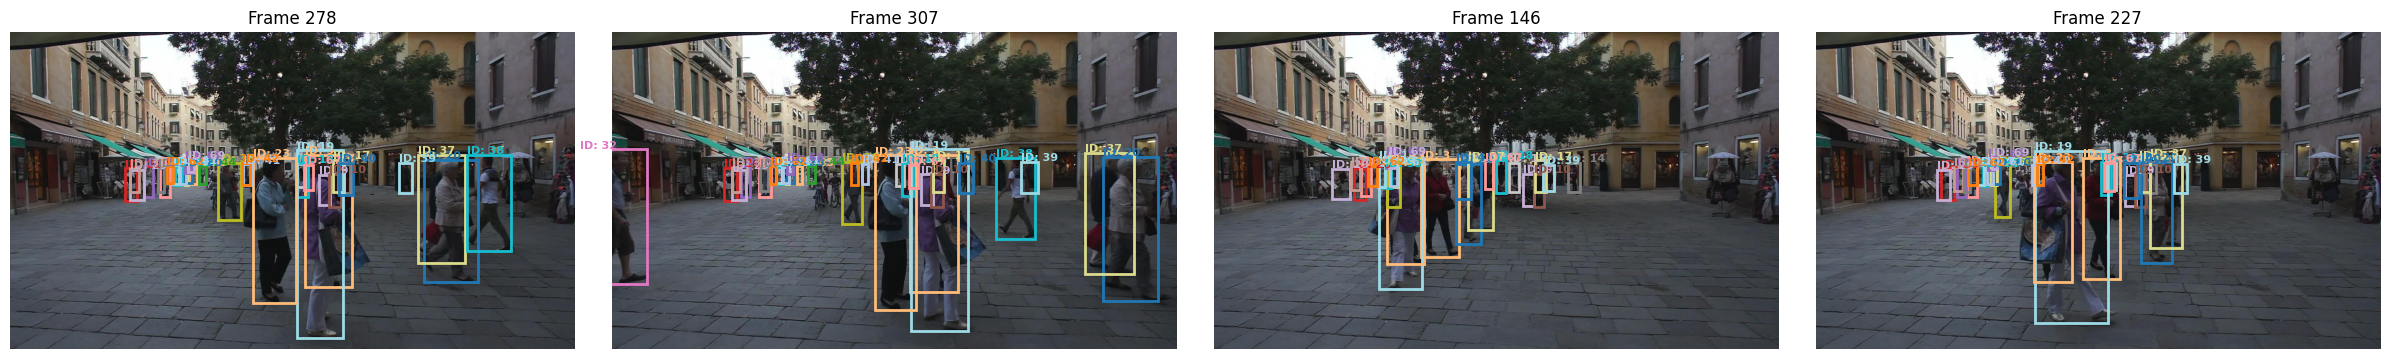

In [9]:
def visualize_sample(image_tensor, target, ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(12, 8))
    img_np = image_tensor.permute(1, 2, 0).numpy()
    ax.imshow(img_np)

    # generate a unique color per object ID
    cmap = plt.colormaps["tab20"]
    boxes = target["boxes"]

    # Check if obj_ids exists (it will, thanks to our Cell 4 fix)
    obj_ids = target.get("obj_ids", torch.arange(boxes.shape[0]))

    for j in range(boxes.shape[0]):
        x1, y1, x2, y2 = boxes[j].tolist()
        obj_id = obj_ids[j].item() # Get the actual pedestrian ID

        # cycle through colormap using the actual ID, so the color stays consistent!
        color = cmap(obj_id % 20)

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        # Display the real object ID on the box
        ax.text(x1, y1 - 5, f"ID: {obj_id}", color=color, fontsize=8, weight="bold")
    ax.axis("off")


def visualize_batch(dataset, num_samples=4, save_dir="vis_output"):
    os.makedirs(save_dir, exist_ok=True)
    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(1, num_samples, figsize=(6 * num_samples, 8))
    if num_samples == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        img_tensor, target = dataset[idx]
        visualize_sample(img_tensor, target, ax=ax)
        ax.set_title(f"Frame {idx + 1}")
    plt.tight_layout()
    save_path = os.path.join(save_dir, "day1_sample_batch.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved to {save_path}")
    plt.show()


# use a dataset without augmentation for clean visualization
vis_dataset = MOTDataset(mot02_path)
visualize_batch(vis_dataset, num_samples=4, save_dir="vis_output")

## Sanity Check Summary

### ✅ Step 1.8 — Sanity Check: Iterate All Training Sequences

This cell performs a **full dataset integrity check** by instantiating `MOTDataset` for each of the seven MOT16 training sequences and counting frames and annotations:

- For each sequence, it sums up all bounding-box annotations across every frame.
- Running totals are accumulated into `grand_total_frames` and `grand_total_annots`.

**What this verifies:**
- All seven sequences load without errors (file paths, GT parsing, frame counting).
- The annotation counts are reasonable and consistent with the MOT16 benchmark statistics.

**Output breakdown:**
| Sequence | Frames | Annotations |
|----------|--------|-------------|
| MOT16-02 | 600 | 17,833 |
| MOT16-04 | 1,050 | 47,557 |
| MOT16-05 | 837 | 6,818 |
| MOT16-09 | 525 | 5,257 |
| MOT16-10 | 654 | 12,318 |
| MOT16-11 | 900 | 9,174 |
| MOT16-13 | 750 | 11,450 |
| **Total** | **5,316** | **110,407** |

This confirms the entire data pipeline (file loading → GT parsing → Dataset indexing) works correctly across all training data.

In [10]:
grand_total_frames = 0
grand_total_annots = 0

for seq in CONFIG["TRAIN_SEQUENCES"]:
    seq_path = os.path.join(CONFIG["MOT16_ROOT"], "train", seq)
    ds = MOTDataset(seq_path)
    n_frames = len(ds)
    n_boxes = sum(len(ds.annotations.get(f + 1, [])) for f in range(n_frames))
    print(f"{seq}: {n_frames} frames, {n_boxes} annotations")
    grand_total_frames += n_frames
    grand_total_annots += n_boxes

print(f"\nGrand total: {grand_total_frames} frames, {grand_total_annots} annotations")
print("Day 1 complete.")

MOT16-02: 600 frames, 17833 annotations
MOT16-04: 1050 frames, 47557 annotations
MOT16-05: 837 frames, 6818 annotations
MOT16-09: 525 frames, 5257 annotations
MOT16-10: 654 frames, 12318 annotations
MOT16-11: 900 frames, 9174 annotations
MOT16-13: 750 frames, 11450 annotations

Grand total: 5316 frames, 110407 annotations
Day 1 complete.


## Step 2: Few-Shot Fine-Tuning — Faster R-CNN

### 🏗️ Step 2.1 — Load Pre-Trained Faster R-CNN and Replace the Classification Head

This cell sets up the object detection model for **few-shot fine-tuning** on MOT16:

1. **Load COCO-pretrained Faster R-CNN** — `fasterrcnn_resnet50_fpn` with `COCO_V1` weights provides a strong backbone (ResNet-50 + Feature Pyramid Network) already trained to detect 91 COCO categories.

2. **Replace the classification head** — The original 91-class head is replaced with a `FastRCNNPredictor(in_features, 2)` for binary classification: `0 = background`, `1 = pedestrian`. The `in_features` (1024) is queried from the existing head to stay architecture-agnostic.

3. **Freeze the backbone** — All parameters in `model.backbone` (ResNet-50 body + FPN neck) are frozen (`requires_grad = False`). Only the **newly initialised RoI head** (box predictor + RPN adjustments) is trainable. This is the "few-shot" strategy: leverage COCO features and only adapt the final classifier.

4. **Count parameters:**
   - Total: ~41.3M parameters (entire model).
   - Trainable: ~14.5M parameters (RPN + RoI head only).

5. **Move to device** — The model is transferred to the selected GPU/MPS/CPU.

**Output:** Downloads the COCO checkpoint (~160 MB), then prints parameter counts and the full model architecture summary.

In [11]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.optim.lr_scheduler import StepLR

NUM_CLASSES = 2  # 0: background, 1: pedestrian

# ── 2.1 Model ──────────────────────────────────────────────────────────────────
model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1)

# cls_score.in_features gives the roi head's input channel count (1024 for ResNet50-FPN)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

# Freeze backbone body + FPN; only the newly initialized head will receive gradients
for param in model.backbone.parameters():
    param.requires_grad = False

params_to_optimize = [p for p in model.parameters() if p.requires_grad]
print(f"Total parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in params_to_optimize):,}")

model.to(CONFIG["DEVICE"])

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 202MB/s]


Total parameters:     41,299,161
Trainable parameters: 14,499,865


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

### 🚂 Step 2.2 — DataLoader, Optimizer, AMP, and Training Loop

This cell performs the actual Faster R-CNN fine-tuning:

**DataLoader Setup:**
- Combines all seven MOT16 training sequences into one `ConcatDataset` (5,316 frames total).
- `batch_size=4` and `num_workers=4` with `pin_memory` for efficient GPU data transfer.
- Uses our custom `collate_fn` since images have variable numbers of boxes.

**Optimizer & Scheduler:**
- **SGD** with `lr=0.005`, `momentum=0.9`, `weight_decay=1e-4` — standard settings for detection fine-tuning.
- **StepLR** decays the learning rate by 10× every 2 epochs: `0.005 → 0.0005 → 0.00005`, allowing fast initial learning with fine refinement later.

**Automatic Mixed Precision (AMP):**
- `GradScaler` + `autocast` cast eligible operations to FP16, **halving memory bandwidth** and enabling larger batch sizes on GPU.
- On non-CUDA devices, AMP is disabled gracefully (`enabled=False` makes it a no-op).

**Training Loop (5 epochs):**
- Each batch of images+targets is moved to the device.
- `model(images, targets)` returns a dict of four losses: `rpn_cls`, `rpn_box`, `roi_cls`, `roi_box`.
- The total loss is back-propagated through the scaler, which handles FP16 overflow automatically.
- After each epoch, the scheduler reduces the LR.

**Output:** Loss decreasing from ~0.62 to ~0.48 across 5 epochs, confirming the model is learning. Weights saved to `fasterrcnn_mot16_finetuned.pth`.

In [12]:
# ── 2.2 DataLoader ─────────────────────────────────────────────────────────────
all_datasets = [
    MOTDataset(
        os.path.join(CONFIG["MOT16_ROOT"], "train", seq),
        transform=get_train_augmentation(),
    )
    for seq in CONFIG["TRAIN_SEQUENCES"]
]
full_train_dataset = torch.utils.data.ConcatDataset(all_datasets)

# 1080×1920 frames are large; batch_size=4 is safe for A100/V100 with AMP.
# Bump to 8 only after confirming headroom via nvidia-smi.
BATCH_SIZE = 4
NUM_WORKERS = 4

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=(CONFIG["DEVICE"].type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)
print(f"Dataset: {len(full_train_dataset)} frames | {len(train_loader)} batches/epoch")

# ── 2.3 Optimizer & Scheduler ──────────────────────────────────────────────────
optimizer = torch.optim.SGD(
    params_to_optimize,
    lr=0.005,
    momentum=0.9,
    weight_decay=1e-4,
)
# Decay LR by 10× every 2 epochs
scheduler = StepLR(optimizer, step_size=2, gamma=0.1)

# ── 2.4 AMP ────────────────────────────────────────────────────────────────────
# GradScaler maintains a running scale factor to prevent FP16 underflow.
# It is a no-op when enabled=False (MPS / CPU fallback).
use_amp = CONFIG["DEVICE"].type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# ── 2.5 Training Loop ──────────────────────────────────────────────────────────
NUM_EPOCHS = 5

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0

    for images, targets in train_loader:
        images  = [img.to(CONFIG["DEVICE"]) for img in images]
        targets = [{k: v.to(CONFIG["DEVICE"]) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)

        # autocast lowers eligible ops to FP16, halving VRAM bandwidth cost.
        # The loss dict contains rpn_cls, rpn_box, roi_cls, and roi_box losses.
        with torch.cuda.amp.autocast(enabled=use_amp):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

        scaler.scale(loss).backward()
        # scaler.step unscales before passing gradients to SGD; skips the step
        # on overflow (NaN/Inf) and adjusts the scale factor automatically.
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]  avg_loss={avg_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}")

torch.save(model.state_dict(), "fasterrcnn_mot16_finetuned.pth")
print("\nStep 2 complete — weights saved to fasterrcnn_mot16_finetuned.pth")

Dataset: 5316 frames | 1329 batches/epoch


/tmp/ipykernel_512/364267525.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_512/364267525.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch [1/5]  avg_loss=0.6223  lr=5.00e-03
Epoch [2/5]  avg_loss=0.5325  lr=5.00e-04
Epoch [3/5]  avg_loss=0.4906  lr=5.00e-04
Epoch [4/5]  avg_loss=0.4826  lr=5.00e-05
Epoch [5/5]  avg_loss=0.4799  lr=5.00e-05

Step 2 complete — weights saved to fasterrcnn_mot16_finetuned.pth


## Step 3: Siamese Network for Re-Identification (Re-ID)

### ⚙️ Step 3.1 — Re-Identification Configuration

This cell defines the hyperparameters for the Siamese Re-ID network in the `REID_CONFIG` dictionary:

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `CROP_H` / `CROP_W` | 128 × 64 | Standard person re-ID crop size (2:1 aspect ratio matches typical pedestrian proportions) |
| `EMBED_DIM` | 256 | Dimensionality of the embedding vector; each person is represented as a 256-D feature |
| `BATCH_SIZE` | 128 | Number of triplets per batch — large batches stabilise triplet loss gradients |
| `NUM_WORKERS` | 4 | Parallel data loading workers |
| `NUM_EPOCHS` | 10 | Full training passes over the identity set |
| `LR` | 1e-3 | Adam learning rate |
| `MARGIN` | 1.0 | Triplet margin — the model must push negative pairs at least this far apart in embedding space |

These imports (`torch.nn`, `Dataset`, `DataLoader`) are also brought in for the Re-ID module.

In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

REID_CONFIG = {
    "CROP_H":      128,
    "CROP_W":      64,
    "EMBED_DIM":   256,
    "BATCH_SIZE":  128,
    "NUM_WORKERS": 4,
    "NUM_EPOCHS":  10,
    "LR":          1e-3,
    "MARGIN":      1.0,
}


### 🧩 Step 3.2 — Triplet Re-ID Dataset

`TripletReIDDataset` prepares training data for the Siamese network using **triplet learning**:

**`__init__` — Build identity gallery (one-time):**
1. Iterates over every frame in all training sequences.
2. Crops each annotated pedestrian from the full frame using ground-truth bounding boxes.
3. Stores crops in a dict keyed by `(sequence_name, object_id)` — the tuple key prevents ID collisions across different sequences (e.g., ID 1 in MOT16-02 ≠ ID 1 in MOT16-04).
4. **Boundary clamping** — Box coordinates are clamped to `[0, W]` / `[0, H]` before cropping. Without this, PIL would pad with black pixels, which would corrupt the embedding space.
5. **Minimum size filter** — Crops smaller than 8×8 pixels are discarded (too small to extract meaningful features).
6. **Identities with < 2 crops are dropped** — At least 2 crops are needed so we can always form a valid (anchor, positive) pair.

**`__getitem__` — Sample a triplet:**
- **Anchor + Positive:** Two random crops of the **same person** (via `random.sample(k=2)`).
- **Negative:** A random crop of a **different person** (resampled until different from the anchor).
- All three crops pass through colour augmentation → resize to 128×64 → tensor conversion → ImageNet normalisation.

**Output:** Prints the number of unique identities and total crops available for training.

In [ ]:
class TripletReIDDataset(Dataset):
    def __init__(self, mot16_root, sequences, crop_h=128, crop_w=64):
        self._augment = transforms.Compose([
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomGrayscale(p=0.1),
        ])
        self._to_tensor = transforms.Compose([
            transforms.Resize((crop_h, crop_w)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

        # Single pass per sequence: open each frame exactly once, crop every
        # annotated pedestrian, and store the raw PIL crop under a
        # (sequence_name, obj_id) key to avoid ID collisions across sequences.
        id_to_crops = defaultdict(list)

        for seq in sequences:
            seq_path = os.path.join(mot16_root, "train", seq)
            annotations = parse_gt_file(os.path.join(seq_path, "gt", "gt.txt"))
            img_dir = os.path.join(seq_path, "img1")

            for frame_idx, annots in annotations.items():
                img_path = os.path.join(img_dir, f"{frame_idx:06d}.jpg")
                if not os.path.exists(img_path):
                    continue

                frame = Image.open(img_path).convert("RGB")
                W_img, H_img = frame.size

                for a in annots:
                    x1, y1, x2, y2 = a["bbox"]
                    # Clamp to frame boundary before cropping; PIL.crop does not
                    # raise on out-of-bounds coords — it pads with black instead,
                    # which poisons the embedding space.
                    x1, x2 = max(0, int(x1)), min(W_img, int(x2))
                    y1, y2 = max(0, int(y1)), min(H_img, int(y2))
                    if (x2 - x1) < 8 or (y2 - y1) < 8:
                        continue
                    id_to_crops[(seq, a["id"])].append(frame.crop((x1, y1, x2, y2)))

        # An identity needs >= 2 crops so we can always draw a non-trivial positive.
        self.id_to_crops = {k: v for k, v in id_to_crops.items() if len(v) >= 2}
        self.ids = list(self.id_to_crops.keys())

        total = sum(len(v) for v in self.id_to_crops.values())
        print(f"TripletReIDDataset ready: {len(self.ids)} identities, {total} crops")

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        anchor_id = self.ids[idx]

        # random.sample(k=2) guarantees anchor != positive without a retry loop.
        anchor_pil, pos_pil = random.sample(self.id_to_crops[anchor_id], 2)

        # Keep resampling until the negative identity differs from the anchor.
        neg_id = anchor_id
        while neg_id == anchor_id:
            neg_id = random.choice(self.ids)
        neg_pil = random.choice(self.id_to_crops[neg_id])

        return self._apply(anchor_pil), self._apply(pos_pil), self._apply(neg_pil)

    def _apply(self, pil_img):
        return self._to_tensor(self._augment(pil_img))


reid_dataset = TripletReIDDataset(
    CONFIG["MOT16_ROOT"],
    CONFIG["TRAIN_SEQUENCES"],
    crop_h=REID_CONFIG["CROP_H"],
    crop_w=REID_CONFIG["CROP_W"],
)


### 🧠 Step 3.3 — Siamese Network Architecture

The `Siamese_Network` is a lightweight CNN that maps a 128×64 person crop to a **256-dimensional embedding vector**:

**CNN Backbone (3 blocks):**
```
Block 1: Conv2d(3→32, 3×3) → BatchNorm → ReLU → MaxPool(2×2)   → 64×32
Block 2: Conv2d(32→64, 3×3) → BatchNorm → ReLU → MaxPool(2×2)  → 32×16
Block 3: Conv2d(64→128, 3×3) → BatchNorm → ReLU → MaxPool(2×2) → 16×8
```
Each block halves the spatial dimensions while increasing channel depth.

**Fully Connected Head:**
```
Flatten(128 × 16 × 8 = 16,384) → Linear(512) → ReLU → Dropout(0.3) → Linear(256)
```

**Design rationale:**
- The architecture is intentionally **compact** — a large backbone (like ResNet) would be overkill for 128×64 crops and would overfit on the limited MOT16 identities.
- `BatchNorm` stabilises training with small crops.
- `Dropout(0.3)` regularises the FC layers to prevent overfitting.
- No final normalisation — L2 normalisation is applied at inference time (see Step 4).

**Output:** Prints the total parameter count of the Siamese network.

In [ ]:
class Siamese_Network(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # Spatial dims after 3x MaxPool2d(2,2) on (H=128, W=64): 16 x 8
        # -> 128 channels * 16 * 8 = 16384 flattened features
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim),
        )

    def forward(self, x):
        return self.fc(self.cnn(x))


siamese = Siamese_Network(embed_dim=REID_CONFIG["EMBED_DIM"]).to(CONFIG["DEVICE"])
print(f"Siamese_Network parameters: {sum(p.numel() for p in siamese.parameters()):,}")


### 🔁 Step 3.4 — Triplet Re-ID Training Loop

This cell trains the Siamese network using **triplet margin loss**:

**Setup:**
- `DataLoader` with `batch_size=128`, `shuffle=True`, `pin_memory=True`, `persistent_workers=True`, and `drop_last=True` (ensures uniform batch sizes for stable training).
- `TripletMarginLoss(margin=1.0)` — For each triplet (anchor, positive, negative):
  ```
  loss = max(0, d(anchor, positive) − d(anchor, negative) + margin)
  ```
  This forces the network to embed same-person crops **closer together** and different-person crops **at least `margin` apart**.
- **Adam optimiser** with `lr=1e-3` — preferred over SGD for embedding networks due to adaptive learning rates.
- **AMP (`GradScaler`)** — Mixed-precision training for speed on CUDA.

**Training Loop (10 epochs):**
- Each batch yields (anchors, positives, negatives) tensors, moved to GPU.
- Forward pass: all three through the Siamese network → compute triplet loss.
- Backward pass: scaled gradients → optimiser step → scaler update.
- Reports per-epoch average triplet loss.

**Output:** Triplet loss should decrease steadily, indicating the network is learning to distinguish individuals. Weights saved to `siamese_reid_mot16.pth`.

In [ ]:
reid_loader = DataLoader(
    reid_dataset,
    batch_size=REID_CONFIG["BATCH_SIZE"],
    shuffle=True,
    num_workers=REID_CONFIG["NUM_WORKERS"],
    pin_memory=True,
    persistent_workers=True,
    drop_last=True,
)

criterion = nn.TripletMarginLoss(margin=REID_CONFIG["MARGIN"])
reid_optimizer = torch.optim.Adam(siamese.parameters(), lr=REID_CONFIG["LR"])
reid_scaler = torch.amp.GradScaler("cuda")

print(f"DataLoader: {len(reid_loader)} batches/epoch  |  batch_size={REID_CONFIG['BATCH_SIZE']}")

for epoch in range(REID_CONFIG["NUM_EPOCHS"]):
    siamese.train()
    epoch_loss = 0.0

    for anchors, positives, negatives in reid_loader:
        anchors   = anchors.to(CONFIG["DEVICE"], non_blocking=True)
        positives = positives.to(CONFIG["DEVICE"], non_blocking=True)
        negatives = negatives.to(CONFIG["DEVICE"], non_blocking=True)

        reid_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            loss = criterion(siamese(anchors), siamese(positives), siamese(negatives))

        reid_scaler.scale(loss).backward()
        reid_scaler.step(reid_optimizer)
        reid_scaler.update()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch + 1:02d}/{REID_CONFIG['NUM_EPOCHS']}]  "
          f"triplet_loss={epoch_loss / len(reid_loader):.4f}")

torch.save(siamese.state_dict(), "siamese_reid_mot16.pth")
print("\nStep 3 complete — weights saved to siamese_reid_mot16.pth")


## Step 4: Inference & Multi-Object Tracking

### 🔧 Step 4.1 — Inference Configuration and Model Loading

This cell sets up the full inference pipeline:

**`INFER_CONFIG` dictionary:**
| Parameter | Value | Purpose |
|-----------|-------|---------|
| `TEST_SEQ` | `MOT16-03` | Sequence to run tracking on |
| `DET_THRESH` | 0.80 | Minimum detection confidence — boxes below this are discarded |
| `SIM_THRESH` | 0.85 | Minimum cosine similarity to match a detection to an existing track |
| `EMA_ALPHA` | 0.90 | Exponential Moving Average weight for gallery prototype updates |
| `OUTPUT_VIDEO` | `mot16_tracked.mp4` | Output file path |
| `FPS` | 25 | Output video frame rate |

**Model loading:**
1. **Detector** — Faster R-CNN is rebuilt (same architecture as Step 2), then loads our fine-tuned weights from `fasterrcnn_mot16_finetuned.pth`. Set to `eval()` mode (disables dropout, batch norm uses running stats).
2. **Re-ID model** — Siamese network is rebuilt, then loads weights from `siamese_reid_mot16.pth`. Also set to `eval()` mode.

Both models run on the same `CONFIG['DEVICE']`.

In [ ]:
import cv2
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import torchvision.transforms.functional as TF

INFER_CONFIG = {
    "TEST_SEQ":     "MOT16-03",
    "DET_THRESH":   0.80,
    "SIM_THRESH":   0.85,
    "EMA_ALPHA":    0.90,
    "OUTPUT_VIDEO": "mot16_tracked.mp4",
    "FPS":          25,
}

detector = fasterrcnn_resnet50_fpn(weights=None)
in_features = detector.roi_heads.box_predictor.cls_score.in_features
detector.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)
detector.load_state_dict(
    torch.load("fasterrcnn_mot16_finetuned.pth", map_location=CONFIG["DEVICE"])
)
detector.eval().to(CONFIG["DEVICE"])

embed_model = Siamese_Network(embed_dim=256)
embed_model.load_state_dict(
    torch.load("siamese_reid_mot16.pth", map_location=CONFIG["DEVICE"])
)
embed_model.eval().to(CONFIG["DEVICE"])

print("Detector and ReID model loaded.")

### 🎯 Step 4.2 — The `Tracker` Class: Cosine-Similarity Matching with Hungarian Assignment

The `Tracker` class maintains a **gallery** of known person embeddings and assigns consistent track IDs across frames:

**`update(embeddings)` algorithm:**
1. **Cold start** — If the gallery is empty (first frame), every detection becomes a new track.

2. **Cost matrix** — `scipy.spatial.distance.cdist` computes pairwise **cosine distance** between all new detection embeddings and all gallery prototypes. The resulting matrix has shape `(N_detections, M_tracks)`.

3. **Hungarian assignment** — `scipy.optimize.linear_sum_assignment` finds the **globally optimal 1-to-1 matching** that minimises total cosine distance. This avoids greedy errors where a nearby match steals a detection from its true owner.

4. **Thresholding** — Only assignments where `cosine_similarity ≥ sim_threshold` (0.85) are accepted. Below-threshold matches are treated as new tracks.

5. **EMA prototype update** — When a detection matches an existing track, the gallery embedding is updated as:
   ```
   gallery[id] = α · gallery[id] + (1 − α) · new_embedding
   ```
   With `α = 0.90`, the prototype **drifts slowly** with pose/lighting changes but is **resistant to single-frame noise** (e.g., partial occlusion).

6. **New tracks** — Unmatched detections are assigned fresh IDs and added to the gallery.

In [ ]:
class Tracker:
    def __init__(self, sim_threshold=0.85, ema_alpha=0.9):
        self.gallery = {}
        self.next_id = 1
        self.sim_threshold = sim_threshold
        self.ema_alpha = ema_alpha

    def update(self, embeddings):
        n = len(embeddings)
        if n == 0:
            return []

        assigned = [-1] * n

        if not self.gallery:
            for i, e in enumerate(embeddings):
                self.gallery[self.next_id] = e
                assigned[i] = self.next_id
                self.next_id += 1
            return assigned

        gids  = list(self.gallery.keys())
        gembs = np.stack([self.gallery[k] for k in gids])  # (M, D)
        dembs = np.stack(embeddings)                         # (N, D)

        # cdist(metric='cosine') produces 1 - cosine_similarity in [0, 2].
        # Shape is (N, M): rows = new detections, columns = gallery tracks.
        cost = cdist(dembs, gembs, metric="cosine")

        # Hungarian algorithm finds the globally-optimal 1-to-1 assignment
        # minimising total cosine distance across all (detection, track) pairs.
        row_ind, col_ind = linear_sum_assignment(cost)

        for r, c in zip(row_ind, col_ind):
            if (1.0 - cost[r, c]) >= self.sim_threshold:
                tid = gids[c]
                assigned[r] = tid
                # EMA blends the stored prototype (weight alpha) with the current
                # observation (weight 1-alpha), letting the gallery drift smoothly
                # with pose/lighting changes without being corrupted by single frames.
                self.gallery[tid] = (
                    self.ema_alpha * self.gallery[tid]
                    + (1.0 - self.ema_alpha) * embeddings[r]
                )

        for i, tid in enumerate(assigned):
            if tid == -1:
                self.gallery[self.next_id] = embeddings[i]
                assigned[i] = self.next_id
                self.next_id += 1

        return assigned

### 🔍 Step 4.3 — Embedding Extraction and Colour Utility

**`_reid_tf` transform pipeline:**
Prepares detection crops for the Siamese network — `Resize(128×64)` → `ToTensor` → `Normalize` (ImageNet stats). This matches the training-time preprocessing exactly.

**`extract_embeddings(frame_rgb, boxes)`:**
1. For each detection box, crops the corresponding region from the RGB frame.
2. Clamps coordinates to frame boundaries (matching the training-time clamping in `TripletReIDDataset`).
3. Handles edge cases: if a crop has zero area, substitutes a small black patch.
4. Stacks all crops into a batch and runs them through the Siamese network in a **single forward pass** (efficient batched inference).
5. **L2-normalises** the output embeddings — after normalisation, cosine similarity equals the dot product, which is faster and numerically stable.

**`id_to_bgr(track_id)`:**
Converts a track ID to a BGR colour using **Knuth's multiplicative hash** (`2654435761`). This hash spreads consecutive integer IDs into visually distinct hues, so adjacent track numbers (e.g., ID 1, ID 2, ID 3) get clearly different colours rather than similar shades.

In [ ]:
_reid_tf = transforms.Compose([
    transforms.Resize((128, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def extract_embeddings(frame_rgb, boxes):
    H, W = frame_rgb.shape[:2]
    crops = []
    for x1, y1, x2, y2 in boxes:
        x1, y1 = max(0, int(x1)), max(0, int(y1))
        x2, y2 = min(W, int(x2)), min(H, int(y2))
        patch = frame_rgb[y1:y2, x1:x2]
        if patch.size == 0:
            patch = np.zeros((64, 32, 3), dtype=np.uint8)
        crops.append(_reid_tf(Image.fromarray(patch)))

    batch = torch.stack(crops).to(CONFIG["DEVICE"])
    with torch.no_grad(), torch.amp.autocast("cuda"):
        embs = embed_model(batch)
    # L2-normalise so cosine similarity == dot product (faster + numerically stable)
    return torch.nn.functional.normalize(embs, dim=1).cpu().numpy()


def id_to_bgr(track_id):
    # Knuth multiplicative hash spreads consecutive IDs into visually distant hues
    h = (track_id * 2654435761) & 0xFFFFFF
    return (h & 0xFF, (h >> 8) & 0xFF, (h >> 16) & 0xFF)

### 🎬 Step 4.4 — Main Tracking Loop and Video Output

This cell runs the full multi-object tracking pipeline and writes an annotated output video:

**Pipeline per frame:**
1. **Read frame** — `cv2.imread` loads the BGR image; `cvtColor` converts to RGB for the detector.

2. **Detect** — The frame is converted to a tensor and passed through the fine-tuned Faster R-CNN. Predictions below `DET_THRESH` (0.80) are discarded.

3. **Embed** — Each surviving detection is cropped, resized, and embedded by the Siamese network via `extract_embeddings()`.

4. **Track** — The `Tracker.update()` matches new embeddings to the gallery using Hungarian assignment + cosine similarity, returning a persistent track ID for each detection.

5. **Draw** — For each matched detection:
   - A coloured bounding box is drawn using `cv2.rectangle`.
   - A label (`ID:N`) is rendered with a filled background for readability.
   - Colour is determined by `id_to_bgr(track_id)` for visual consistency.

6. **Write** — The annotated frame is appended to the output video via `cv2.VideoWriter`.

**Output:** Prints the output file path, total frames processed, and the number of unique track IDs assigned across the sequence.

In [ ]:
seq_path = os.path.join(CONFIG["MOT16_ROOT"], "test", INFER_CONFIG["TEST_SEQ"])
if not os.path.isdir(seq_path):
    seq_path = os.path.join(CONFIG["MOT16_ROOT"], "train", INFER_CONFIG["TEST_SEQ"])
print(f"Running on: {seq_path}")

frame_paths = sorted(
    glob.glob(os.path.join(seq_path, "img1", "*.jpg")),
    key=lambda p: int(os.path.splitext(os.path.basename(p))[0]),
)

_sample = cv2.imread(frame_paths[0])
H_out, W_out = _sample.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(
    INFER_CONFIG["OUTPUT_VIDEO"], fourcc, INFER_CONFIG["FPS"], (W_out, H_out)
)

tracker = Tracker(
    sim_threshold=INFER_CONFIG["SIM_THRESH"],
    ema_alpha=INFER_CONFIG["EMA_ALPHA"],
)

for frame_path in frame_paths:
    frame_bgr = cv2.imread(frame_path)
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    img_t = TF.to_tensor(frame_rgb).to(CONFIG["DEVICE"])
    with torch.no_grad(), torch.amp.autocast("cuda"):
        preds = detector([img_t])[0]

    scores = preds["scores"].cpu().numpy()
    boxes  = preds["boxes"].cpu().numpy()
    boxes  = boxes[scores >= INFER_CONFIG["DET_THRESH"]]

    if len(boxes) > 0:
        embs = extract_embeddings(frame_rgb, boxes)
        tids = tracker.update(list(embs))
    else:
        tids = []

    for box, tid in zip(boxes, tids):
        x1, y1, x2, y2 = map(int, box)
        color = id_to_bgr(tid)
        cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), color, 2)
        label = f"ID:{tid}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(frame_bgr, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, cv2.FILLED)
        cv2.putText(
            frame_bgr, label, (x1 + 2, y1 - 4),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA,
        )

    writer.write(frame_bgr)

writer.release()
print(
    f"Saved to {INFER_CONFIG['OUTPUT_VIDEO']}  "
    f"({len(frame_paths)} frames, {len(tracker.gallery)} unique IDs)"
)